In [1]:
import pandas as pd
import numpy as np
import os
import glob

# 1. DANH SÁCH ĐẶC TRƯNG (Giữ nguyên 25 đặc trưng xịn)
SELECTED_FEATURES = [
    'IAT', 'syn_flag_number', 'psh_flag_number', 'fin_flag_number', 
    'rst_flag_number', 'ack_flag_number', 'Tot sum', 'Protocol Type', 
    'flow_duration', 'Rate', 'Std', 'Variance', 'UDP', 'TCP', 'HTTP', 
    'HTTPS', 'DNS', 'Duration', 'Number', 'ICMP', 'Magnitue', 
    'Header_Length', 'AVG', 'Min', 'Max'
]

# 2. CẤU HÌNH ĐƯỜNG DẪN
INPUT_DIR = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/' 
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
OUTPUT_DATA = '/kaggle/working/layer2_spoofing_2labels_data.csv.gz'
SAMPLES_PER_FILE = 100000 # Số lượng mẫu tối đa cho mỗi file

# 3. DANH SÁCH 2 NHÃN SPOOFING CHI TIẾT
# (Tên chuẩn khớp với dataset gốc)
TARGET_SPOOFING_LABELS = [
    'MITM-ArpSpoofing', 
    'DNS_Spoofing'
]

def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

def process_layer2_spoofing():
    label_lookup = pd.read_csv(LABEL_MAP_PATH)
    first_write = True
    
    csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
    print(f"Bắt đầu quy trình trích xuất Spoofing (2 nhãn chi tiết) trên {len(csv_files)} file...")

    # Khởi tạo bộ đếm cho 2 nhãn
    group_counts = {label: 0 for label in TARGET_SPOOFING_LABELS}

    for file_path in csv_files:
        # Đọc nhãn từ file
        temp_df = pd.read_csv(file_path, nrows=1)
        if 'label' not in temp_df.columns: continue
        label_id = temp_df['label'].iloc[0]
        
        # Tìm tên nhãn gốc
        match = label_lookup[label_lookup['Encoded_ID'] == label_id]
        if match.empty: continue
        original_name = match['Original_Label'].values[0]
        
        # LỌC: Chỉ xử lý nếu nhãn nằm trong danh sách 2 loại Spoofing
        if original_name not in TARGET_SPOOFING_LABELS:
            continue
            
        # Đọc dữ liệu với các cột đã chọn
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in SELECTED_FEATURES if c in available_cols]
        df_full = pd.read_csv(file_path, usecols=use_cols)
        
        # Dọn dẹp dữ liệu
        df_cleaned = basic_clean(df_full)
        if len(df_cleaned) == 0: continue
        
        # Lấy mẫu ngẫu nhiên
        num_sample = min(len(df_cleaned), SAMPLES_PER_FILE)
        df_sampled = df_cleaned.sample(n=num_sample, random_state=42)
        
        # Gán nhãn trực tiếp bằng tên chủng loại (GIỮ NGUYÊN CHỮ)
        df_sampled['layer2_label'] = original_name
        group_counts[original_name] += num_sample
        
        # Ghi file (nối tiếp nếu đã có dữ liệu)
        if first_write:
            df_sampled.to_csv(OUTPUT_DATA, index=False, compression='gzip')
            first_write = False
        else:
            df_sampled.to_csv(OUTPUT_DATA, mode='a', index=False, header=False, compression='gzip')
            
        print(f"Đã trích xuất: {original_name} -> {num_sample} dòng")
        del df_full, df_cleaned, df_sampled

    print("\n--- TỔNG KẾT DỮ LIỆU SPOOFING (2 NHÃN) ---")
    for label, count in group_counts.items():
        if count > 0:
            print(f"{label}: {count} dòng")
    print(f"\nFile đã được lưu tại: {OUTPUT_DATA}")
    print("--- HOÀN TẤT ---")

if __name__ == "__main__":
    process_layer2_spoofing()

Bắt đầu quy trình trích xuất Spoofing (2 nhãn chi tiết) trên 34 file...
Đã trích xuất: MITM-ArpSpoofing -> 100000 dòng
Đã trích xuất: DNS_Spoofing -> 100000 dòng

--- TỔNG KẾT DỮ LIỆU SPOOFING (2 NHÃN) ---
MITM-ArpSpoofing: 100000 dòng
DNS_Spoofing: 100000 dòng

File đã được lưu tại: /kaggle/working/layer2_spoofing_2labels_data.csv.gz
--- HOÀN TẤT ---


=> Đang tải dữ liệu Spoofing (2 nhãn: ARP Spoofing, DNS Spoofing)...
Các nhóm Spoofing nhận diện: ['DNS_Spoofing', 'MITM-ArpSpoofing'] (Sẽ được map thành 0 và 1)

=> Bắt đầu huấn luyện và đánh giá 5-Fold CV cho họ Spoofing (Binary Classification)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1310]	valid_0's binary_logloss: 0.157837
   + Hoàn thành Fold 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1447]	valid_0's binary_logloss: 0.159574
   + Hoàn thành Fold 2
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1362]	valid_0's binary_logloss: 0.158586
   + Hoàn thành Fold 3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1451]	valid_0's binary_logloss: 0.159611
   + Hoàn thành Fold 4
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1145]	val

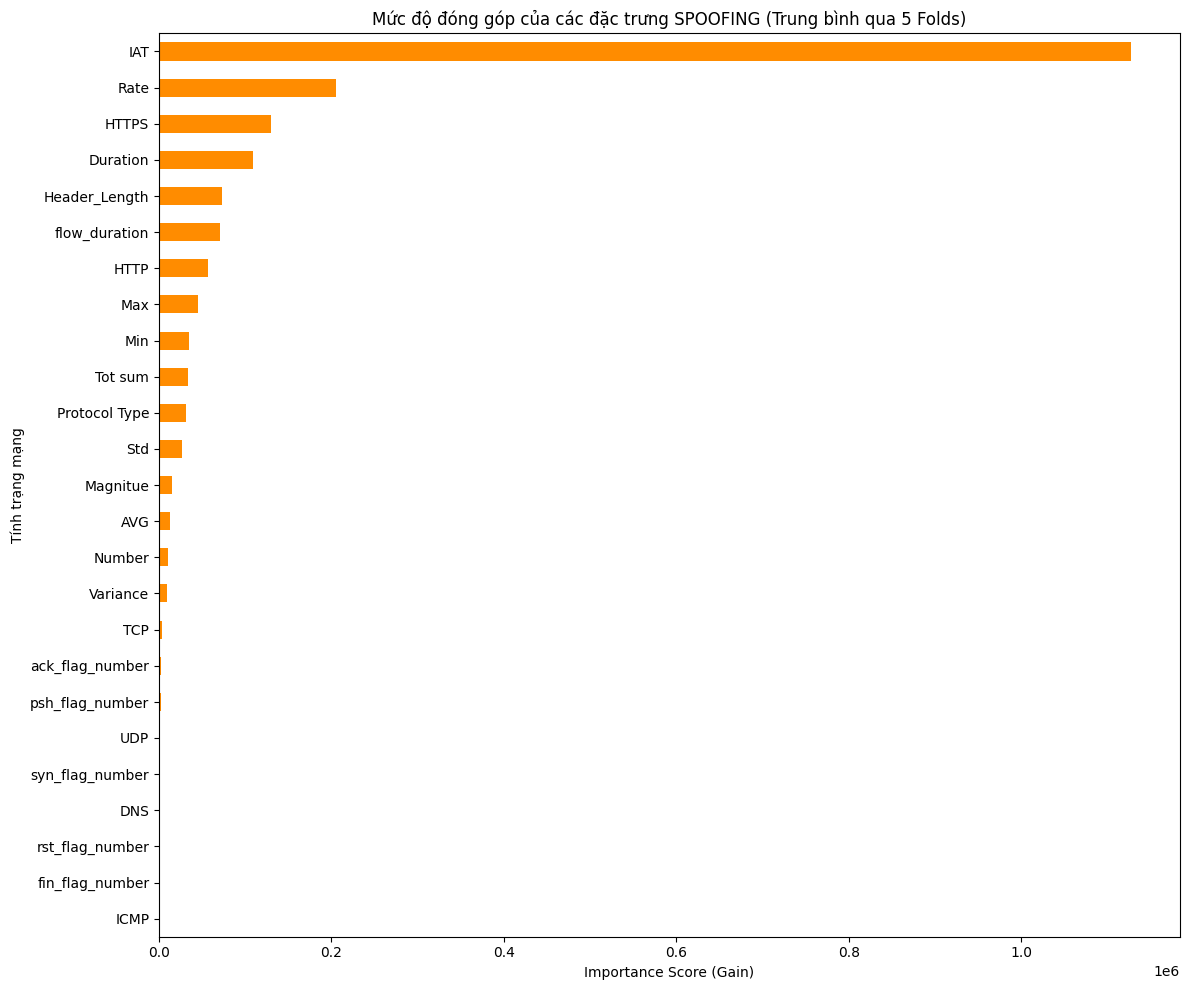

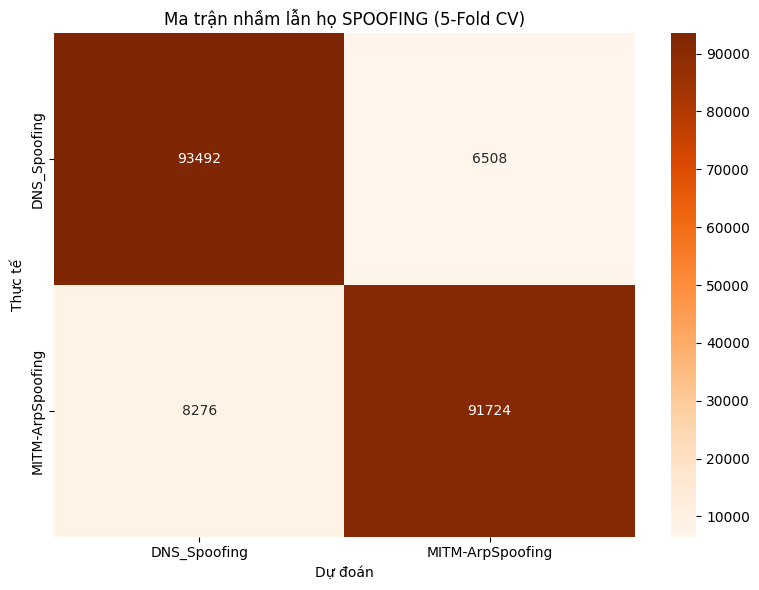

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# --- 1. CẤU HÌNH ---
# Trỏ đúng vào file Spoofing cậu vừa xuất
INPUT_FILE = '/kaggle/working/layer2_spoofing_2labels_data.csv.gz'
K_FOLDS = 5

print("=> Đang tải dữ liệu Spoofing (2 nhãn: ARP Spoofing, DNS Spoofing)...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# Tách Features và Target (Cột nhãn ở bước trước lưu là 'layer2_label')
target_col = 'layer2_label' if 'layer2_label' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y_raw = df[target_col]

# Chuyển đổi nhãn sang số (0 và 1) để LightGBM xử lý dạng Binary
le = LabelEncoder()
y = pd.Series(le.fit_transform(y_raw))
target_names = le.classes_
print(f"Các nhóm Spoofing nhận diện: {list(target_names)} (Sẽ được map thành 0 và 1)")

# --- 2. THIẾT LẬP K-FOLD ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_metrics = []
all_latency = []
oof_preds = np.zeros(len(df))
feature_importance_df = pd.DataFrame() 

print(f"\n=> Bắt đầu huấn luyện và đánh giá {K_FOLDS}-Fold CV cho họ Spoofing (Binary Classification)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Cấu hình tham số LightGBM cho bài toán Binary
    params = {
        'objective': 'binary', # THAY ĐỔI: Chuyển sang binary
        'metric': 'binary_logloss', # THAY ĐỔI: Dùng binary_logloss
        'learning_rate': 0.05, 
        'num_leaves': 63, 
        'max_bin': 255,
        'min_data_in_leaf': 50,
        'device': 'cpu', 
        'verbose': -1, 
        'seed': 42
    }
    
    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)
    
    model = lgb.train(
        params, 
        train_set, 
        valid_sets=[val_set], 
        num_boost_round=2000, 
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    # Dự đoán và đo thời gian
    start_pred = time.time()
    y_prob = model.predict(X_val) # Trả về xác suất class 1
    end_pred = time.time()
    
    # THAY ĐỔI: Ngưỡng 0.5 để quyết định nhãn 0 hoặc 1
    y_pred = (y_prob >= 0.5).astype(int)
    oof_preds[val_idx] = y_pred
    
    # Tính Latency (ms/sample)
    latency_per_sample = (end_pred - start_pred) / len(X_val)
    all_latency.append(latency_per_sample)
    
    # Lưu Feature Importance
    fold_imp = pd.DataFrame({
        'Feature': X.columns, 
        'Importance': model.feature_importance(importance_type='gain')
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)
    
    # THAY ĐỔI: Cập nhật 'average' thành 'binary' cho các hàm đánh giá
    fold_metrics.append({
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='binary'),
        'recall': recall_score(y_val, y_pred, average='binary'),
        'f1': f1_score(y_val, y_pred, average='binary')
    })
    print(f"   + Hoàn thành Fold {fold+1}")

# --- 3. TỔNG HỢP KẾT QUẢ ---
metrics_df = pd.DataFrame(fold_metrics)
avg_metrics = metrics_df.mean()
std_metrics = metrics_df.std()
avg_latency_ms = np.mean(all_latency) * 1000

print("\n" + "="*50)
print(f"⭐ KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ({K_FOLDS}-FOLD) - HỌ SPOOFING (BINARY)")
print("-" * 50)
print(f"1. Accuracy:  {avg_metrics['accuracy']:.4f} (±{std_metrics['accuracy']:.4f})")
print(f"2. Precision: {avg_metrics['precision']:.4f} (±{std_metrics['precision']:.4f})")
print(f"3. Recall:    {avg_metrics['recall']:.4f} (±{std_metrics['recall']:.4f})")
print(f"4. F1-Score:  {avg_metrics['f1']:.4f} (±{std_metrics['f1']:.4f})")
print("-" * 50)
print(f"⏱ Tốc độ dự đoán trung bình: {avg_latency_ms:.6f} ms/dòng")
print("="*50)

# Báo cáo chi tiết
print("\nBáo cáo phân loại chi tiết (Out-of-Fold):")
print(classification_report(y, oof_preds, target_names=target_names))

# --- 4. BIỂU ĐỒ TÁC ĐỘNG ĐẶC TRƯNG ---
plt.figure(figsize=(12, 10))
mean_imp = feature_importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=True)
mean_imp.plot(kind='barh', color='darkorange')
plt.title(f'Mức độ đóng góp của các đặc trưng SPOOFING (Trung bình qua {K_FOLDS} Folds)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Tính trạng mạng')
plt.tight_layout()
plt.savefig('/kaggle/working/spoofing_feature_importance.png')
plt.show()

# --- 5. MA TRẬN NHẦM LẪN ---
cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Ma trận nhầm lẫn họ SPOOFING ({K_FOLDS}-Fold CV)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig('/kaggle/working/spoofing_confusion_matrix.png')
plt.show()

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from sklearn.preprocessing import LabelEncoder

# --- 1. CẤU HÌNH ---
INPUT_FILE         = '/kaggle/working/layer2_spoofing_2labels_data.csv.gz'
MODEL_SAVE_PATH    = '/kaggle/working/lightgbm_layer2_spoofing_2labels_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_spoofing_2labels_encoder.pkl'
META_DATA_PATH     = '/kaggle/working/layer2_spoofing_2labels_meta.pkl'

print("=> Đang tải dữ liệu Spoofing (2 nhãn) để huấn luyện...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# --- 2. TÁCH X VÀ y ---
X     = df.drop(columns=['layer2_label'])
y_raw = df['layer2_label']

# --- 3. MÃ HÓA NHÃN ---
print("=> Đang mã hóa nhãn và lưu LabelEncoder...")
le = LabelEncoder()
y  = le.fit_transform(y_raw)

with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)
print(f"   + Đã nhận diện các lớp: {list(le.classes_)}")

# --- 4. THAM SỐ (Binary vì chỉ có 2 nhãn) ---
params = {
    'objective':  'binary',
    'metric':     'binary_logloss',
    'is_unbalance': True,
    'learning_rate': 0.015,
    'num_leaves':  255,
    'max_bin':     511,
    'device':      'cpu',
    'verbose':     -1,
    'seed':        42
}

# --- 5. HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ---
print(f"\n=> Đang huấn luyện mô hình Spoofing trên toàn bộ {len(df):,} dòng...")
start_time = time.time()

train_set   = lgb.Dataset(X, label=y)
final_model = lgb.train(params, train_set, num_boost_round=2000)

print(f"\n=> Huấn luyện hoàn tất trong {time.time() - start_time:.2f} giây.")

# --- 6. LƯU MÔ HÌNH VÀ META ---
final_model.save_model(MODEL_SAVE_PATH)
print(f"   [+] Đã lưu mô hình tại: {MODEL_SAVE_PATH}")

model_info = {
    'features':  list(X.columns),
    'num_class': 2
}
with open(META_DATA_PATH, 'wb') as f:
    pickle.dump(model_info, f)
print(f"   [+] Đã lưu meta tại   : {META_DATA_PATH}")
print(f"   [+] Đã lưu encoder tại: {LABEL_ENCODER_PATH}")
print("\n=> HỆ THỐNG SPOOFING (2 NHÃN) ĐÃ SẴN SÀNG!")


=> Đang tải dữ liệu Spoofing (2 nhãn) để huấn luyện...
=> Đang mã hóa nhãn và lưu LabelEncoder...
   + Đã nhận diện các lớp: ['DNS_Spoofing', 'MITM-ArpSpoofing']

=> Đang huấn luyện mô hình Spoofing trên toàn bộ 200,000 dòng...

=> Huấn luyện hoàn tất trong 49.63 giây.
   [+] Đã lưu mô hình tại: /kaggle/working/lightgbm_layer2_spoofing_2labels_model.txt
   [+] Đã lưu meta tại   : /kaggle/working/layer2_spoofing_2labels_meta.pkl
   [+] Đã lưu encoder tại: /kaggle/working/layer2_spoofing_2labels_encoder.pkl

=> HỆ THỐNG SPOOFING (2 NHÃN) ĐÃ SẴN SÀNG!


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import os
import glob
import random

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
MODEL_PATH         = '/kaggle/working/lightgbm_layer2_spoofing_2labels_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_spoofing_2labels_encoder.pkl'
META_DATA_PATH     = '/kaggle/working/layer2_spoofing_2labels_meta.pkl'

INPUT_DIR      = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/'
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'

TARGET_SPOOFING_LABELS = ['MITM-ArpSpoofing', 'DNS_Spoofing']

print("=> Đang khởi động hệ thống AI Spoofing 2 nhãn...")
model = lgb.Booster(model_file=MODEL_PATH)
with open(LABEL_ENCODER_PATH, 'rb') as f: le = pickle.load(f)
with open(META_DATA_PATH,     'rb') as f: expected_features = pickle.load(f)['features']

# ==========================================
# 2. SINH TRỌNG SỐ ĐẶC TRƯNG
# ==========================================
print("\n" + "="*50)
print("⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (SPOOFING)")
print("="*50)

weights   = model.feature_importance(importance_type='gain')
weight_df = pd.DataFrame({
    'Feature':       expected_features,
    'Weight (Gain)': weights
})
weight_df = weight_df.sort_values(by='Weight (Gain)', ascending=False)
weight_df['Contribution (%)'] = (weight_df['Weight (Gain)'] / weight_df['Weight (Gain)'].sum()) * 100

print(weight_df.head(10).to_string(index=False))
weight_df.to_csv('/kaggle/working/layer2_spoofing_2labels_feature_weights.txt', index=False, sep='\t')
print("\n[+] Đã lưu trọng số Spoofing tại: layer2_spoofing_2labels_feature_weights.txt")

# ==========================================
# 3. THUẬT TOÁN GOM RỔ DỮ LIỆU ĐẢM BẢO ĐỦ 10 MẪU
# ==========================================
print("\n" + "="*60)
print("🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC")
print("="*60)

csv_files    = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
label_lookup = pd.read_csv(LABEL_MAP_PATH)
label_dict   = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

random.shuffle(csv_files)
sample_pool      = []
target_count     = 10
samples_per_file = 4

print("=> Đang rải lưới quét dữ liệu Spoofing...")

for file_path in csv_files:
    temp_df = pd.read_csv(file_path, nrows=1)
    if 'label' not in temp_df.columns: continue

    label_id      = temp_df['label'].iloc[0]
    original_name = label_dict.get(label_id, "")

    if original_name in TARGET_SPOOFING_LABELS:
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols       = [c for c in expected_features if c in available_cols]

        df_raw     = pd.read_csv(file_path, usecols=use_cols)
        df_cleaned = df_raw.replace([np.inf, -np.inf], np.nan).dropna()

        if len(df_cleaned) > 0:
            take_n     = min(len(df_cleaned), samples_per_file)
            df_sampled = df_cleaned.sample(n=take_n)
            df_sampled['True_Answer'] = original_name
            sample_pool.append(df_sampled)

    if sum(len(d) for d in sample_pool) >= target_count * 2:
        break

# ==========================================
# 4. CHỐT SỔ VÀ DỰ ĐOÁN
# ==========================================
if not sample_pool:
    print("⚠️ Không tìm thấy mẫu Spoofing nào.")
else:
    master_df = pd.concat(sample_pool, ignore_index=True)

    if len(master_df) >= target_count:
        test_df = master_df.sample(n=target_count).reset_index(drop=True)
    else:
        test_df = master_df.sample(frac=1.0).reset_index(drop=True)

    true_labels = test_df['True_Answer'].tolist()
    X_test      = test_df[expected_features].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Binary model: predict() trả về 1D array xác suất của class 1
    y_prob         = model.predict(X_test)
    y_pred_indices = (y_prob > 0.5).astype(int)
    confidences    = np.where(y_prob > 0.5, y_prob, 1 - y_prob) * 100
    y_pred_names   = le.inverse_transform(y_pred_indices)

    correct_count = 0
    for i in range(len(test_df)):
        is_correct = (true_labels[i] == y_pred_names[i])
        if is_correct: correct_count += 1

        print(f"STT {i+1}:")
        print(f"   - Thực tế: {true_labels[i]}")
        print(f"   - AI đoán: {y_pred_names[i]} (Độ tự tin: {confidences[i]:.2f}%)")
        print(f"   => {'✅ CHÍNH XÁC' if is_correct else '❌ SAI LỆCH'}")
        print("-" * 45)

    print(f"🏆 TỔNG KẾT: Đúng {correct_count}/{len(test_df)} mẫu.")


=> Đang khởi động hệ thống AI Spoofing 2 nhãn...

⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (SPOOFING)
      Feature  Weight (Gain)  Contribution (%)
          IAT   4.637886e+06         54.321171
         Rate   8.779428e+05         10.282893
        HTTPS   5.386730e+05          6.309200
     Duration   5.025512e+05          5.886124
Header_Length   3.546160e+05          4.153435
flow_duration   3.347259e+05          3.920472
         HTTP   2.287784e+05          2.679563
          Max   2.135798e+05          2.501550
          Min   1.721930e+05          2.016808
      Tot sum   1.598717e+05          1.872495

[+] Đã lưu trọng số Spoofing tại: layer2_spoofing_2labels_feature_weights.txt

🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC
=> Đang rải lưới quét dữ liệu Spoofing...
STT 1:
   - Thực tế: MITM-ArpSpoofing
   - AI đoán: MITM-ArpSpoofing (Độ tự tin: 100.00%)
   => ✅ CHÍNH XÁC
---------------------------------------------
STT 2:
   - Thực tế: MITM-ArpSpoofing
   - AI đoán: M